# Ring resonator sweep analysis

Pipeline for the Siglent scope CSVs in `O-drive - Jeppe/QTLab/Data`. Each file has
`time_s, CH1_volts, CH2_volts, CH3_volts` where:

- **CH1** = laser sweep trigger (a sharp ~8&nbsp;V pulse marks sweep start, and a second identical
  pulse ~1.37&nbsp;s later marks the start of the *next* sweep, i.e. the end of this one)
- **CH2** = MZI response (clean interference fringes, used as a ruler to linearize the
  non-uniform laser tuning speed)
- **CH3** = ring resonator transmission (small photodiode signal; needs the dark-signal offset
  removed)

Every ~0.25&nbsp;nm the laser mode-hops, producing a brief damped-ringing glitch simultaneously in
CH2 and CH3. These are detected and masked out before the frequency axis is built and before
resonances are fit -- see the note in the mode-hop section on why this masking has to be
resolution-aware.

The frequency axis is self-calibrated: MZI fringes are counted to linearize the sweep, and the
total fringe count is scaled onto the approximate 1536-1563&nbsp;nm span (update
`WAVELENGTH_START_NM`/`WAVELENGTH_END_NM` below once the exact sweep range is known).


In [83]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from scipy.ndimage import label
from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\QTLab\Data")
DARK_FILE = DATA_DIR / "dark_signal.csv"

# Rough sweep bounds (nm). Sweep runs largest -> smallest wavelength as time increases.
# Update these once the exact calibration is known -- the frequency axis rescales from them.
WAVELENGTH_START_NM = 1563.0
WAVELENGTH_END_NM = 1536.0
SPEED_OF_LIGHT = 299_792_458.0

TRIGGER_THRESHOLD_V = 4.0

# Mode-hop glitch detection (hysteresis on a high-frequency energy metric -- see note below)
GLITCH_ENERGY_WINDOW_S = 22e-6
GLITCH_ZSCORE_HIGH = 10.0   # core: samples confidently inside a mode-hop
GLITCH_ZSCORE_LOW = 3.0     # samples kept in the mask only if contiguous with a core sample

BASELINE_WINDOW_GHZ = 60.0         # rolling-baseline window used only for *finding* candidates
MIN_RESONANCE_SPACING_GHZ = 150.0  # less than the ~300 GHz ring FSR
RESONANCE_PROMINENCE = 0.2         # dip depth (in the rough normalized view) to flag a candidate
FIT_HALF_WINDOW_GHZ = 8.0          # local fit window -- mode hops are only ~31 GHz apart


In [84]:
def MZI_transfer_function(I_0, V, frequency, f0, delay_length, phase=0):
    """
    Calculate the transfer function of a Mach-Zehnder Interferometer (MZI).

    Parameters:
    frequency : array-like
        The frequency values at which to evaluate the transfer function.
    f0 : float
        The central frequency of the MZI.
    delay_length : float
        The length of the delay line in the MZI.

    Returns:
    array-like
        The transfer function values at the specified frequencies.
    """
    c = 3e8  # Speed of light in m/s
    n_g = 1.4792  # Group index of the waveguide
    delta_f_fringe = c / (n_g * delay_length)  # MZI free spectral range, in Hz

    # NB: fixed a bug here -- the fringe period is delta_f_fringe (Hz), not delay_length (m).
    return I_0 * 0.5 * (1 - V * np.cos(2 * np.pi * (frequency - f0) / delta_f_fringe + phase))


def ring_normalization(dark_signal, transmission_signal):
    """
    Normalize the transmission signal of a ring resonator by subtracting the dark signal.

    Parameters:
    dark_signal : array-like
        The dark signal (background noise) to be subtracted.
    transmission_signal : array-like
        The raw transmission signal to be normalized.

    Returns:
    array-like
        The normalized transmission signal.
    """
    dark_average = np.average(dark_signal)
    transmission_signal_altered = transmission_signal - dark_average

    max_transmission_altered = np.max(transmission_signal_altered)

    return (transmission_signal_altered) / (max_transmission_altered)


def amplitude_lorentzian(amplitude_after_loss, transmission_coupling):
    """
    Calculate the amplitude of a Lorentzian function based on the amplitude after loss and transmission coupling

    Parameters:
    amplitude_after_loss : float
    The amplitude of the signal after accounting for losses.
    transmission_coupling : float
    The absolute value of the transmission coupling of the signal.
    """
    b = amplitude_after_loss * transmission_coupling

    a = amplitude_after_loss
    t = transmission_coupling

    return (1 - a**2) * (1 - t**2) / (1 - b**2)


def Lorentzian(f, f0, linewidth):
    """
    Calculate the Lorentzian function.

    Parameters:
    f : array-like
        The frequency values at which to evaluate the Lorentzian function.
    f0 : float
        The central frequency of the Lorentzian.
    linewidth : float
        The full width at half maximum (FWHM) of the Lorentzian.

    Returns:
    array-like
        The Lorentzian function values at the specified frequencies.
    """
    return (linewidth / 2) ** 2 / ((f - f0) ** 2 + (linewidth / 2) ** 2)


def ring_transmission(f, f_0, A, linewidth):
    """
    Calculate the transmission of a ring resonator based on the Lorentzian function.

    Parameters:
    f : array-like
        The frequency values at which to evaluate the transmission.
    f_0 : float
        The central frequency of the Lorentzian.
    A : float
        The amplitude of the Lorentzian function.
    linewidth : float
        The full width at half maximum (FWHM) of the Lorentzian.

    Returns:
    array-like
        The transmission values of the ring resonator at the specified frequencies.
    """
    return 1 - A * Lorentzian(f, f_0, linewidth)


def local_ring_model(f, f0, A, linewidth, slope, offset):
    """ring_transmission riding on a locally linear background (laser power / coupling drift).

    Needed because a single mode-hop-free window is often too short for the slow envelope to be
    flat -- fitting it out here (rather than pre-flattening the whole spectrum) keeps the fit
    honest about what part of the window is background vs. resonance.
    """
    baseline = offset + slope * (f - f0)
    return baseline * ring_transmission(f, f0, A, linewidth)


## Loading, dark offset, trigger segmentation

`dark_signal.csv` was taken with the ring path blocked, so its CH3 average is the photodiode's
dark level (fed into `ring_normalization` above). CH1/CH2 don't need dark-offsetting.


In [85]:
def load_sweep(path):
    """Load one scope CSV, skipping the '#'-commented header lines."""
    df = pd.read_csv(path, comment="#")
    return df["time_s"].values, df["CH1_volts"].values, df["CH2_volts"].values, df["CH3_volts"].values


_, _, _, _dark_ch3 = load_sweep(DARK_FILE)
CH3_DARK_OFFSET = float(np.average(_dark_ch3))
print(f"CH3 dark offset: {CH3_DARK_OFFSET:.6f} V")


def find_sweep_segment(t, ch1, threshold=TRIGGER_THRESHOLD_V):
    """Return (i0, i1) bounding one full sweep, from the CH1 trigger's rising edges.

    The trigger fires once at sweep start and again ~1.37 s later at the start of the next
    sweep (= end of this one). If only one edge is captured in the file, fall back to using
    the last sample as the end point.
    """
    above = ch1 > threshold
    rises = np.where(np.diff(above.astype(int)) == 1)[0]
    if len(rises) >= 2:
        return rises[0], rises[1]
    if len(rises) == 1:
        return rises[0], len(t) - 1
    raise ValueError("No trigger edge found above threshold")


CH3 dark offset: -0.006668 V


## Mode-hop masking

A mode hop shows up as a burst of high-frequency energy simultaneously in CH2 and CH3. The mask
uses **hysteresis** rather than a fixed dilation margin: a sample only joins the mask if it's
contiguous with a high-confidence ("core") glitch sample *and* still above a weaker secondary
threshold. This matters because a fixed time margin (e.g. "pad 600&nbsp;us either side") behaves
very differently depending on the sample rate -- at 500&nbsp;kHz that's 300 samples in a spectrum
where a resonance spans thousands of samples (harmless), but at the 5&nbsp;kHz quick-sweep files
it's ~3 samples out of only ~5-10 that span the *entire* resonance, which was silently deleting
the real dips next to a mode hop and replacing them with a straight interpolation line. Hysteresis
grows each glitch to its own natural extent instead, so it adapts automatically.


In [86]:
def _rolling_std(x, window):
    kernel = np.ones(window) / window
    mean = np.convolve(x, kernel, mode="same")
    mean_sq = np.convolve(x * x, kernel, mode="same")
    return np.sqrt(np.clip(mean_sq - mean**2, 0, None))


def _zscore(energy):
    med = np.median(energy)
    mad = np.median(np.abs(energy - med))
    return (energy - med) / (1.4826 * mad + 1e-12)


def detect_mode_hops(t, ch2, ch3):
    """Boolean mask, True where CH2/CH3 show a mode-hop glitch (to be masked out)."""
    dt = np.median(np.diff(t))
    win = max(3, int(round(GLITCH_ENERGY_WINDOW_S / dt)))

    energy2 = _rolling_std(np.diff(ch2, prepend=ch2[0]), win)
    energy3 = _rolling_std(np.diff(ch3, prepend=ch3[0]), win)
    z = np.maximum(_zscore(energy2), _zscore(energy3))

    core = z > GLITCH_ZSCORE_HIGH
    weak = z > GLITCH_ZSCORE_LOW
    labels, _ = label(weak)
    core_labels = set(labels[core & (labels > 0)])
    return np.isin(labels, list(core_labels)) if core_labels else np.zeros_like(core)


def mask_and_interpolate(t, signal, mask):
    """Replace masked (glitch) samples with a linear interpolation across the gap."""
    good = ~mask
    cleaned = signal.copy()
    cleaned[mask] = np.interp(t[mask], t[good], signal[good])
    return cleaned


## Time -> frequency axis via MZI fringe counting

The laser doesn't tune linearly in time, so a straight `linspace` between the trigger times would
distort resonance shapes. Instead we count MZI fringes (each half-fringe = a fixed, but unknown,
frequency step) to build a monotonic "optical phase clock", then self-calibrate its overall scale
using the rough wavelength span, so the fringe spacing doesn't need to be known in advance.


In [87]:
def find_mzi_extrema(t, ch2_clean, dt):
    """Alternating peak/trough sample indices of the (glitch-cleaned) MZI trace."""
    min_dist = max(1, int(round(0.003 / dt)))  # << expected fringe half-period
    peaks, _ = find_peaks(ch2_clean, distance=min_dist, prominence=0.5)
    troughs, _ = find_peaks(-ch2_clean, distance=min_dist, prominence=0.5)

    idx = np.concatenate([peaks, troughs])
    kind = np.concatenate([np.ones(len(peaks)), -np.ones(len(troughs))])
    order = np.argsort(idx)
    idx, kind = idx[order], kind[order]

    # Enforce strict peak/trough alternation: on a same-type run, keep only the most extreme.
    clean_idx = [idx[0]]
    clean_kind = [kind[0]]
    for i in range(1, len(idx)):
        if kind[i] == clean_kind[-1]:
            is_more_extreme = (
                ch2_clean[idx[i]] > ch2_clean[clean_idx[-1]]
                if kind[i] == 1
                else ch2_clean[idx[i]] < ch2_clean[clean_idx[-1]]
            )
            if is_more_extreme:
                clean_idx[-1] = idx[i]
        else:
            clean_idx.append(idx[i])
            clean_kind.append(kind[i])
    return np.array(clean_idx)


def build_frequency_axis(t, ch2, glitch_mask):
    """Return freq (Hz), monotonic increasing with t, self-calibrated to the rough sweep span."""
    dt = np.median(np.diff(t))
    ch2_clean = mask_and_interpolate(t, ch2, glitch_mask)
    extrema = find_mzi_extrema(t, ch2_clean, dt)

    fringe_count = np.arange(len(extrema)) * 0.5
    t_extrema = t[extrema]

    interior = PchipInterpolator(t_extrema, fringe_count, extrapolate=False)
    phase = interior(t)

    # Linear extrapolation (using the edge fringe rate) outside the first/last extremum,
    # since cubic extrapolation is not guaranteed monotonic there.
    slope_start = (fringe_count[1] - fringe_count[0]) / (t_extrema[1] - t_extrema[0])
    slope_end = (fringe_count[-1] - fringe_count[-2]) / (t_extrema[-1] - t_extrema[-2])
    before = t < t_extrema[0]
    after = t > t_extrema[-1]
    phase[before] = fringe_count[0] + slope_start * (t[before] - t_extrema[0])
    phase[after] = fringe_count[-1] + slope_end * (t[after] - t_extrema[-1])

    f_start = SPEED_OF_LIGHT / (WAVELENGTH_START_NM * 1e-9)
    f_end = SPEED_OF_LIGHT / (WAVELENGTH_END_NM * 1e-9)
    n_total = fringe_count[-1] - fringe_count[0]

    freq = f_start + (phase - phase[0]) / n_total * (f_end - f_start)
    fsr_eff_ghz = (f_end - f_start) / n_total / 1e9
    return freq, fsr_eff_ghz


## Resonance finding + fitting

Candidates are located on a rolling-baseline-normalized view of the spectrum (just to find *where*
the dips are). Each candidate is then fit on its own tight local window (±`FIT_HALF_WINDOW_GHZ`,
well inside the ~31&nbsp;GHz mode-hop spacing) using `local_ring_model` -- their `ring_transmission`
Lorentzian riding on a locally linear background -- fit directly to the dark-corrected,
glitch-masked raw signal. `n_points_in_fwhm` is reported explicitly for every fit rather than
silently gating on it: on the quick 5&nbsp;kHz files that's often only ~3-10 points, which is
enough to get a fit but means the linewidth carries real uncertainty -- worth weighing per
resonance rather than a single blanket cutoff.


In [88]:
def _rolling_baseline(freq_ghz, signal):
    """Rolling 90th-percentile envelope -- only used to locate candidate dips, not to fit them."""
    samples_per_ghz = len(freq_ghz) / (freq_ghz[-1] - freq_ghz[0])
    win = int(BASELINE_WINDOW_GHZ * samples_per_ghz)
    win = max(win + (win % 2 == 0), 3)

    s = pd.Series(signal)
    baseline = s.rolling(win, center=True, min_periods=1).quantile(0.9)
    win2 = max(win // 2, 1) | 1
    return baseline.rolling(win2, center=True, min_periods=1).mean().values


def find_and_fit_resonances(freq_ghz, ch3_clean):
    """Locate resonance dips and fit each locally. Returns a list of result dicts."""
    baseline = _rolling_baseline(freq_ghz, ch3_clean)
    rough_norm = ch3_clean / baseline

    samples_per_ghz = len(freq_ghz) / (freq_ghz[-1] - freq_ghz[0])
    distance = int(MIN_RESONANCE_SPACING_GHZ * samples_per_ghz)
    peak_idx, _ = find_peaks(-rough_norm, prominence=RESONANCE_PROMINENCE, distance=distance)

    results = []
    for p in peak_idx:
        window = (freq_ghz > freq_ghz[p] - FIT_HALF_WINDOW_GHZ) & (
            freq_ghz < freq_ghz[p] + FIT_HALF_WINDOW_GHZ
        )
        x, y = freq_ghz[window], ch3_clean[window]

        f0_guess = x[np.argmin(y)]
        offset_guess = np.median(y)
        amp_guess = np.clip(1 - y.min() / offset_guess, 0.05, 0.95)
        p0 = [f0_guess, amp_guess, 1.5, 0.0, offset_guess]
        bounds = (
            [f0_guess - 3, 0, 0.3, -0.05, 0],
            [f0_guess + 3, 1.0, FIT_HALF_WINDOW_GHZ, 0.05, 2 * offset_guess],
        )

        try:
            popt, pcov = curve_fit(local_ring_model, x, y, p0=p0, bounds=bounds, maxfev=20000)
            perr = np.sqrt(np.diag(pcov))
        except RuntimeError:
            continue

        f0, amplitude, fwhm_ghz, slope, offset = popt
        n_points_in_fwhm = int(np.sum((x > f0 - fwhm_ghz / 2) & (x < f0 + fwhm_ghz / 2)))
        residual = y - local_ring_model(x, *popt)
        results.append(
            {
                "f0_ghz_rel": f0,
                "fwhm_ghz": fwhm_ghz,
                "fwhm_ghz_err": perr[2],
                "amplitude": amplitude,
                "slope": slope,
                "offset": offset,
                "loaded_Q": (SPEED_OF_LIGHT / (WAVELENGTH_START_NM * 1e-9) + f0 * 1e9) / (fwhm_ghz * 1e9),
                "n_points_in_fwhm": n_points_in_fwhm,
                "fit_rms_residual": float(np.sqrt(np.mean(residual**2))),
                # A fit pinned at the window's own edge or built from almost no points inside
                # its own FWHM isn't trustworthy -- flag it rather than silently reporting it.
                "unreliable_fit": bool(fwhm_ghz > 0.9 * FIT_HALF_WINDOW_GHZ or n_points_in_fwhm < 2),
            }
        )
    return results


## Full per-file pipeline


C:\Users\au617810\AppData\Local\Temp\ipykernel_32552\1587111711.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


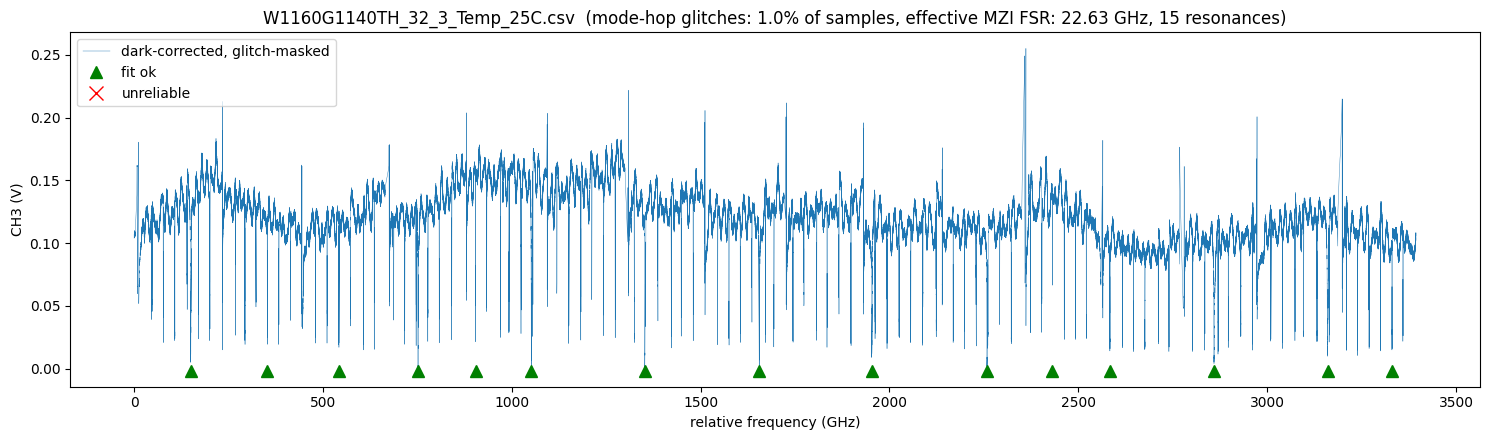

,file,f0_ghz_rel,fwhm_ghz,fwhm_ghz_err,amplitude,slope,offset,loaded_Q,n_points_in_fwhm,fit_rms_residual,unreliable_fit,wavelength_nm,fwhm_mhz
0,W1160G1140TH_32_3_Temp_25C.csv,149.915121,2.003507,0.005560,0.967624,-0.001347,0.143026,95809.849665,478,0.002949,False,1561.779316,2003.507062
1,W1160G1140TH_32_3_Temp_25C.csv,352.838396,0.819612,0.011082,0.754395,0.000665,0.124705,234450.613429,173,0.006788,False,1560.130046,819.612416
2,W1160G1140TH_32_3_Temp_25C.csv,542.227650,0.462253,0.009368,0.884988,-0.000012,0.117427,416109.830856,102,0.008988,False,1558.593915,462.253013
3,W1160G1140TH_32_3_Temp_25C.csv,751.899759,1.803471,0.033037,0.980817,0.000440,0.125026,106770.615028,403,0.016299,False,1556.896794,1803.470880
4,W1160G1140TH_32_3_Temp_25C.csv,904.096708,0.545787,0.011553,0.709215,0.000969,0.154035,353086.419118,122,0.010698,False,1555.667200,545.786758
5,W1160G1140TH_32_3_Temp_25C.csv,1051.857181,1.734241,0.033163,0.941296,0.000538,0.156031,111205.786429,390,0.020224,False,1554.475304,1734.241164
6,W1160G1140TH_32_3_Temp_25C.csv,1352.554871,1.885525,0.029247,0.916123,0.000024,0.127797,102442.759745,436,0.013562,False,1552.055388,1885.524664
7,W1160G1140TH_32_3_Temp_25C.csv,1655.434640,1.407124,0.014527,1.000000,-0.000551,0.113726,137486.961300,282,0.007413,False,1549.625515,1407.124196
8,W1160G1140TH_32_3_Temp_25C.csv,1953.336803,2.579550,0.014211,0.899975,0.002412,0.122129,75113.542624,526,0.004578,False,1547.242986,2579.549909
9,W1160G1140TH_32_3_Temp_25C.csv,2258.776818,2.908918,0.052063,0.855924,0.000799,0.118212,66713.668543,568,0.013758,False,1544.807766,2908.917712


In [89]:
def analyze_file(path, dark_offset=CH3_DARK_OFFSET, plot=True):
    """Run the full pipeline on one sweep file. Returns (results_df, freq_ghz, ch3_clean)."""
    t, ch1, ch2, ch3_raw = load_sweep(path)
    ch3 = ch3_raw - dark_offset

    i0, i1 = find_sweep_segment(t, ch1)
    t, ch2, ch3 = t[i0:i1], ch2[i0:i1], ch3[i0:i1]

    glitch_mask = detect_mode_hops(t, ch2, ch3)
    ch3_clean = mask_and_interpolate(t, ch3, glitch_mask)

    freq, fsr_eff_ghz = build_frequency_axis(t, ch2, glitch_mask)
    freq_ghz = (freq - freq[0]) / 1e9

    resonances = find_and_fit_resonances(freq_ghz, ch3_clean)

    results_df = pd.DataFrame(resonances)
    if not results_df.empty:
        results_df["wavelength_nm"] = SPEED_OF_LIGHT / (
            (SPEED_OF_LIGHT / (WAVELENGTH_START_NM * 1e-9) + results_df["f0_ghz_rel"] * 1e9)
        ) * 1e9
        results_df["fwhm_mhz"] = results_df["fwhm_ghz"] * 1e3
        results_df.insert(0, "file", path.name)

    if plot:
        fig, ax = plt.subplots(figsize=(15, 4.5))
        ax.plot(freq_ghz, ch3_clean, lw=0.3, label="dark-corrected, glitch-masked")
        if not results_df.empty:
            reliable = ~results_df["unreliable_fit"]
            ymin = ch3_clean.min()
            ax.plot(results_df.loc[reliable, "f0_ghz_rel"],
                     np.full(reliable.sum(), ymin), "g^", ms=8, label="fit ok")
            ax.plot(results_df.loc[~reliable, "f0_ghz_rel"],
                     np.full((~reliable).sum(), ymin), "rx", ms=10, label="unreliable")
        ax.set_xlabel("relative frequency (GHz)")
        ax.set_ylabel("CH3 (V)")
        ax.set_title(f"{path.name}  (mode-hop glitches: {glitch_mask.mean()*100:.1f}% of samples,"
                      f" effective MZI FSR: {fsr_eff_ghz:.2f} GHz, {len(results_df)} resonances)")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return results_df, freq_ghz, ch3_clean


# Sanity check on a high-resolution (500 kHz) file and a quick (5 kHz) file.
_hires_results, _, _ = analyze_file(DATA_DIR / "W1160G1140TH_32_3_Temp_25C.csv")
_hires_results


## Verifying individual resonance fits

The overview plot above only marks *where* each fit landed. To actually judge whether a fit is
trustworthy you need to see the local data against the fit curve -- `plot_resonance_fits` draws
one small panel per resonance (data points + the fitted `local_ring_model` curve), so every
resonance in a file can be checked by eye in one figure. Panels for `unreliable_fit` resonances
are outlined in red.


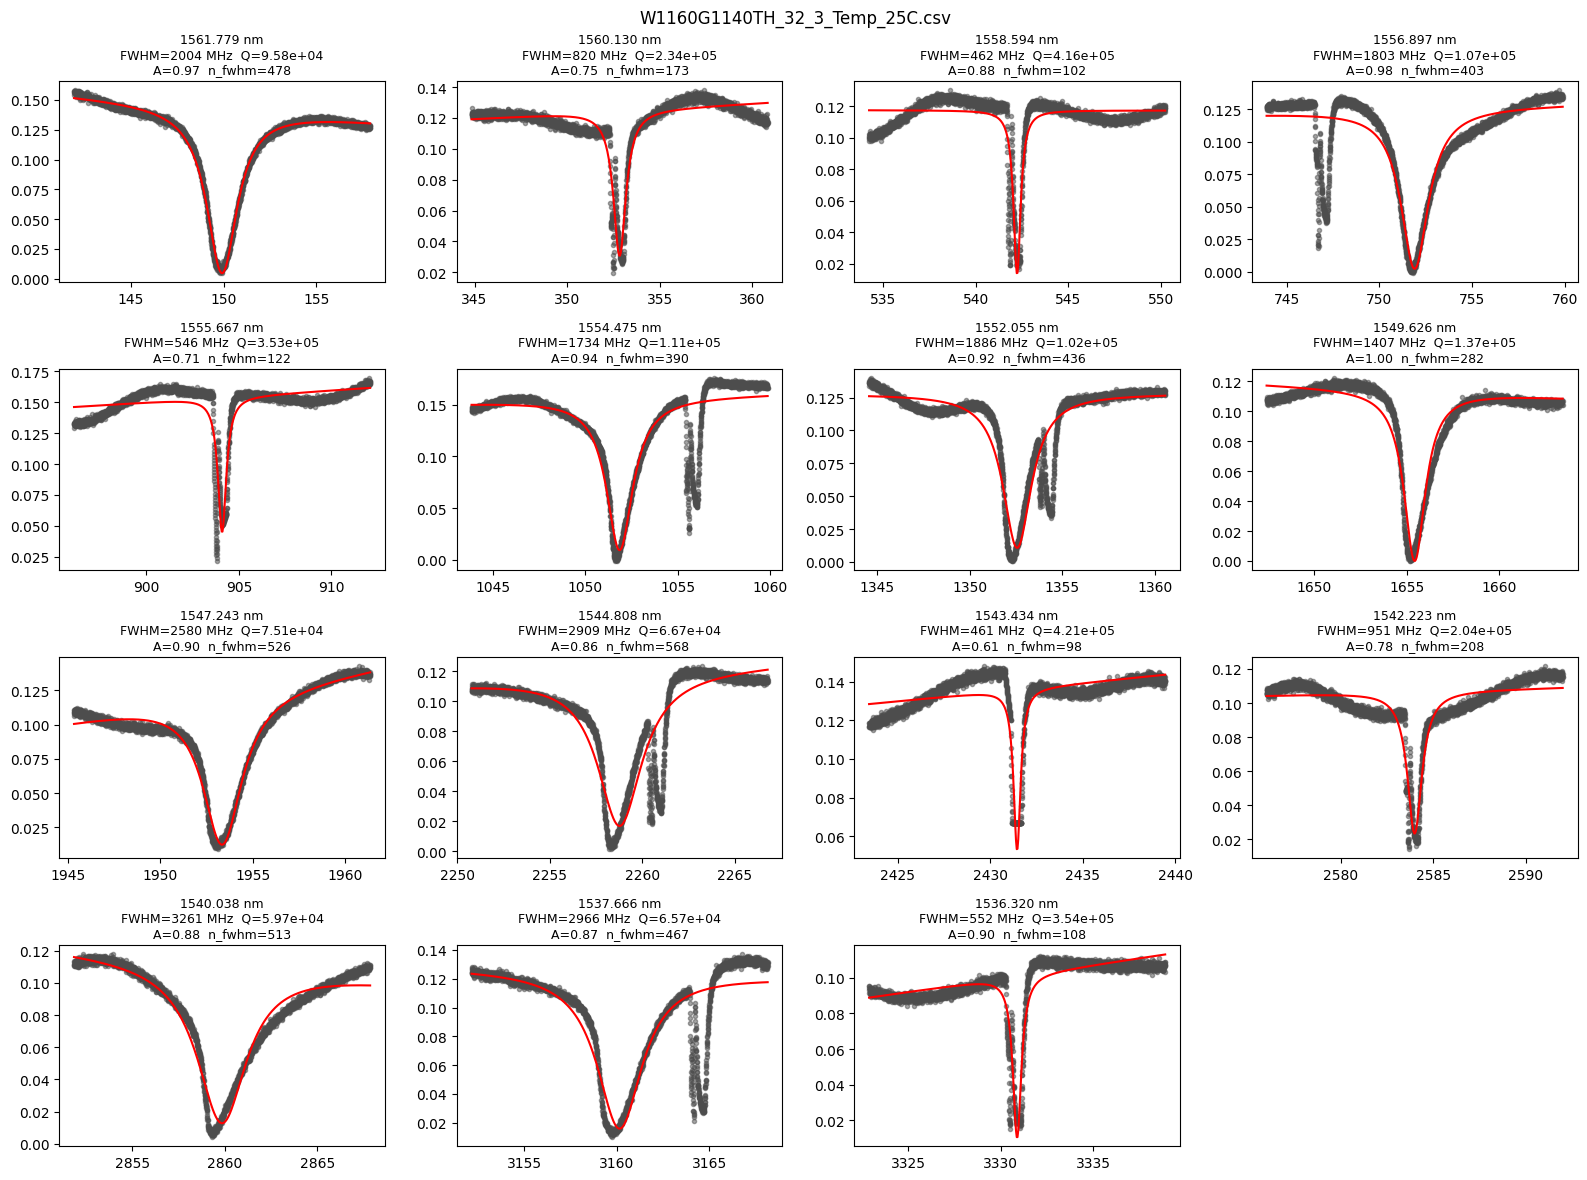

In [90]:
def plot_resonance_fits(path, indices=None, n_cols=4):
    """Grid of data+fit panels, one per resonance, for visual verification.

    indices: optional list/slice into the file's resonance table (in frequency order) to show
    only some resonances, e.g. indices=range(4) for just the first four. Default shows all.
    """
    results_df, freq_ghz, ch3_clean = analyze_file(path, plot=False)
    rows = results_df if indices is None else results_df.iloc[indices]
    n = len(rows)
    if n == 0:
        print(f"No resonances found in {path.name}")
        return results_df

    n_cols = max(1, min(n_cols, n))
    n_rows = -(-n // n_cols)  # ceil
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

    for ax, (_, row) in zip(axs.flat, rows.iterrows()):
        window = (freq_ghz > row.f0_ghz_rel - FIT_HALF_WINDOW_GHZ) & (
            freq_ghz < row.f0_ghz_rel + FIT_HALF_WINDOW_GHZ
        )
        x, y = freq_ghz[window], ch3_clean[window]
        xx = np.linspace(x.min(), x.max(), 400)
        yy = local_ring_model(xx, row.f0_ghz_rel, row.amplitude, row.fwhm_ghz, row.slope, row.offset)

        ax.plot(x, y, "o", ms=3, alpha=0.5, color="0.3")
        ax.plot(xx, yy, "r-", lw=1.5)
        ax.set_title(
            f"{row.wavelength_nm:.3f} nm\n"
            f"FWHM={row.fwhm_mhz:.0f} MHz  Q={row.loaded_Q:.2e}\n"
            f"A={row.amplitude:.2f}  n_fwhm={row.n_points_in_fwhm}",
            fontsize=9,
        )
        if row.unreliable_fit:
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(2)

    for ax in axs.flat[n:]:
        ax.axis("off")

    fig.suptitle(path.name)
    plt.tight_layout()
    plt.show()
    return results_df


# Show every resonance found in the high-resolution 25 C file.
_ = plot_resonance_fits(DATA_DIR / "W1160G1140TH_32_3_Temp_25C.csv")


### Note on the quick (5 kHz) device-screening files

Earlier version of this notebook wrote these files off as unfittable, because a fixed-time
mode-hop mask margin was silently deleting the real (narrow) resonance next to every mode hop and
replacing it with a straight interpolation line -- see the hysteresis note above for the fix. With
that fixed, real dips do come through with as few as ~5 points inside the FWHM, matching what was
seen by eye in the raw data. `n_points_in_fwhm` and `unreliable_fit` are reported per resonance so
the extra uncertainty on these files (vs. the 500&nbsp;kHz temperature series) stays visible
instead of implied.


## Batch: every sweep file

Runs the same pipeline on all device-screening files and all temperature-series files, collects
one results table, and saves it next to the data.


In [91]:
all_files = sorted(p for p in DATA_DIR.glob("*.csv") if re.match(r"W\d+G\d+", p.name))
print(f"{len(all_files)} sweep files found")

all_results = []
for path in all_files:
    temp_match = re.search(r"_Temp_(\d+)C", path.name)
    df, _, _ = analyze_file(path, plot=False)
    if df.empty:
        continue
    df["temperature_c"] = int(temp_match.group(1)) if temp_match else np.nan
    all_results.append(df)
    print(f"{path.name}: {len(df)} resonances "
          f"({df['unreliable_fit'].sum()} unreliable)")

results = pd.concat(all_results, ignore_index=True)

out_path = DATA_DIR / "resonance_fit_results.csv"
results.to_csv(out_path, index=False)
print(f"\n{len(results)} resonances total, saved to {out_path}")

results[["file", "temperature_c", "wavelength_nm", "fwhm_mhz", "amplitude",
         "loaded_Q", "n_points_in_fwhm", "unreliable_fit"]]


15 sweep files found
W1100G1250SH_24_3.csv: 16 resonances (5 unreliable)
W1160G1090FF_30_1.csv: 15 resonances (5 unreliable)
W1160G1090TH_30_2.csv: 15 resonances (4 unreliable)
W1160G1090TH_30_3.csv: 14 resonances (5 unreliable)
W1160G1140FF_32_1.csv: 13 resonances (1 unreliable)
W1160G1140SH_32_2.csv: 14 resonances (3 unreliable)
W1160G1140TH_32_3.csv: 15 resonances (3 unreliable)
W1160G1140TH_32_3_Temp_20C.csv: 14 resonances (0 unreliable)
W1160G1140TH_32_3_Temp_25C.csv: 15 resonances (0 unreliable)
W1160G1140TH_32_3_Temp_30C.csv: 14 resonances (0 unreliable)
W1160G1140TH_32_3_Temp_35C.csv: 12 resonances (0 unreliable)
W1160G1140TH_32_3_Temp_40C.csv: 12 resonances (0 unreliable)
W1160G1190FF_31_1.csv: 13 resonances (2 unreliable)
W1160G1190SH_31_3.csv: 13 resonances (4 unreliable)
W1160G1190TH_31_2.csv: 15 resonances (6 unreliable)

210 resonances total, saved to C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\QTLab\Data\resonance_fit_results.csv


,file,temperature_c,wavelength_nm,fwhm_mhz,amplitude,loaded_Q,n_points_in_fwhm,unreliable_fit
0,W1100G1250SH_24_3.csv,NaN,1562.568411,8000.000000,0.191958,23982.346623,18,True
1,W1100G1250SH_24_3.csv,NaN,1561.114972,1904.513450,0.238980,100832.786763,4,False
2,W1100G1250SH_24_3.csv,NaN,1558.973255,2016.015890,0.698632,95386.757812,5,False
3,W1100G1250SH_24_3.csv,NaN,1557.703062,5035.862411,0.352410,38217.491125,8,False
4,W1100G1250SH_24_3.csv,NaN,1556.497652,1242.904837,0.689615,154965.261952,2,False
...,...,...,...,...,...,...,...,...
205,W1160G1190TH_31_2.csv,NaN,1544.041359,8000.000000,0.377024,24270.112341,14,True
206,W1160G1190TH_31_2.csv,NaN,1542.243270,1617.399856,0.351325,120185.041840,4,False
207,W1160G1190TH_31_2.csv,NaN,1539.811365,1566.938762,0.299787,124251.362093,3,False
208,W1160G1190TH_31_2.csv,NaN,1538.450533,8000.000000,0.225567,24358.311462,16,True


### Bonus: temperature dependence (optional, only 5 data points)

The next plot only uses the 5 `_Temp_20/25/30/35/40C` files for device `W1160G1140TH_32_3` -- it
is **not** part of the main gap-sweep analysis below. It matches up resonances across those 5
files by their order in frequency (`#0` = lowest-frequency resonance, etc.) and plots how each
one's wavelength and FWHM shift with temperature. With only 5 temperatures per line and up to 15
resonances, the legend gets busy -- feel free to skip this cell or subset `clean` to a couple of
`resonance_index` values if it's not useful.


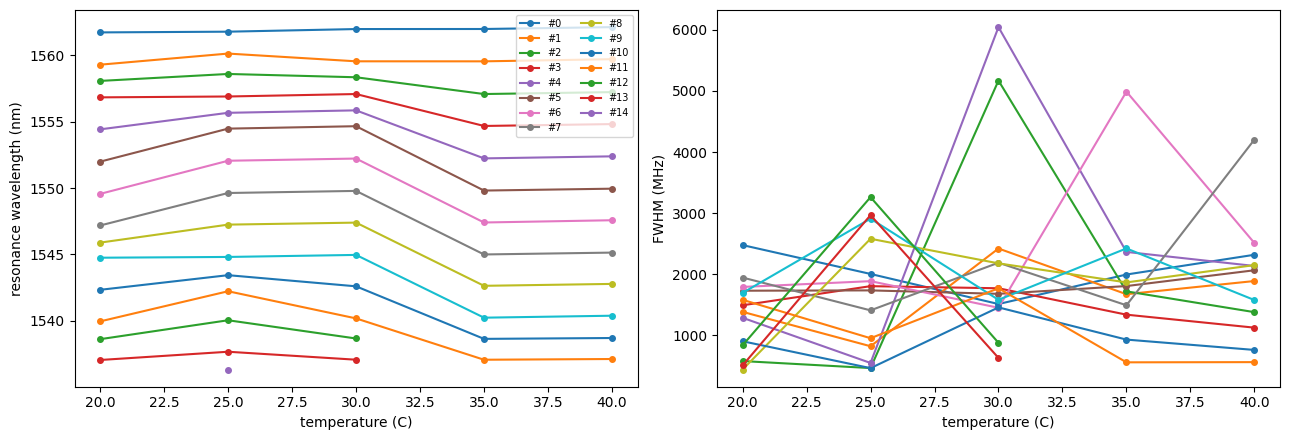

In [92]:
# Bonus: wavelength/linewidth vs temperature for the temperature series (resonance_index tracks
# the same physical resonance across temperatures by its order within each file).
temp_results = results.dropna(subset=["temperature_c"])
clean = temp_results[~temp_results["unreliable_fit"]].copy()
clean["resonance_index"] = clean.groupby("temperature_c").cumcount()

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for idx, group in clean.groupby("resonance_index"):
    group = group.sort_values("temperature_c")
    axs[0].plot(group["temperature_c"], group["wavelength_nm"], "o-", ms=4, label=f"#{idx}")
    axs[1].plot(group["temperature_c"], group["fwhm_mhz"], "o-", ms=4, label=f"#{idx}")
axs[0].set_xlabel("temperature (C)"); axs[0].set_ylabel("resonance wavelength (nm)")
axs[1].set_xlabel("temperature (C)"); axs[1].set_ylabel("FWHM (MHz)")
axs[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## FSR per file

`loaded_Q` is already in the results table (from the fit's FWHM). FSR isn't a fit output -- it's
the spacing between consecutive resonances -- so it's computed here from `f0_ghz_rel`.

A plain median of consecutive spacings isn't robust enough on its own: a handful of files contain
a few extra low-amplitude, low-confidence dips roughly halfway between two real resonances
(visible in `plot_resonance_fits` as the shallow/wide panels) which drag a naive median toward
half the true FSR. `estimate_fsr_ghz` restricts to spacings within a plausible window around your
stated ~2&nbsp;nm (~250-320&nbsp;GHz at 1550&nbsp;nm) and takes the histogram mode of what's left,
which reproduces the same ~301&nbsp;GHz FSR on 13 of the 15 files straight from the data. For the
2 files where that still fails (too few resonances landing in-window), it falls back to the
median FSR across all *other* files -- reasonable since gap changes barely perturb a ring's FSR,
only its coupling.


In [93]:
PLAUSIBLE_FSR_GHZ = (250.0, 320.0)  # from your ~2 nm estimate at ~1550 nm; widen if needed


def estimate_fsr_ghz(f0_sorted, plausible=PLAUSIBLE_FSR_GHZ):
    """Robust FSR from consecutive resonance spacings; np.nan if nothing lands in-window."""
    diffs = np.diff(np.sort(f0_sorted))
    in_range = diffs[(diffs > plausible[0]) & (diffs < plausible[1])]
    if len(in_range) == 0:
        return np.nan, np.nan, 0
    hist, edges = np.histogram(in_range, bins=15)
    mode_center = 0.5 * (edges[np.argmax(hist)] + edges[np.argmax(hist) + 1])
    near = in_range[np.abs(in_range - mode_center) < 0.1 * mode_center]
    near = near if len(near) else in_range
    return np.median(near), np.std(near), len(near)


reliable = results[~results["unreliable_fit"]]
per_file = []
for fname, g in reliable.groupby("file"):
    fsr, fsr_std, n_used = estimate_fsr_ghz(g["f0_ghz_rel"].values)
    per_file.append({"file": fname, "n_resonances": len(g), "fsr_ghz": fsr,
                      "fsr_std_ghz": fsr_std, "n_diffs_used": n_used})
per_file = pd.DataFrame(per_file)

# Fall back to the across-file median FSR for files where too few spacings landed in-window.
global_fsr = per_file["fsr_ghz"].median()
needs_fallback = per_file["fsr_ghz"].isna() | (per_file["n_diffs_used"] < 2)
per_file["used_global_fallback"] = needs_fallback
per_file.loc[needs_fallback, "fsr_ghz"] = global_fsr

print(f"Global median FSR across files: {global_fsr:.2f} GHz "
      f"({global_fsr / SPEED_OF_LIGHT * (WAVELENGTH_START_NM*1e-9)**2 * 1e9:.3f} nm at "
      f"{WAVELENGTH_START_NM:.0f} nm)")
per_file


Global median FSR across files: 301.77 GHz (0.000 nm at 1563 nm)


,file,n_resonances,fsr_ghz,fsr_std_ghz,n_diffs_used,used_global_fallback
0,W1100G1250SH_24_3.csv,11,301.772696,0.000000,1,True
1,W1160G1090FF_30_1.csv,10,301.772696,0.000000,1,True
2,W1160G1090TH_30_2.csv,11,299.938134,12.852721,6,False
3,W1160G1090TH_30_3.csv,9,301.026806,3.576171,5,False
4,W1160G1140FF_32_1.csv,12,301.979694,2.280673,8,False
5,W1160G1140SH_32_2.csv,11,302.347779,2.370783,6,False
6,W1160G1140TH_32_3.csv,12,303.358961,3.290784,4,False
7,W1160G1140TH_32_3_Temp_20C.csv,14,300.250373,2.244776,7,False
8,W1160G1140TH_32_3_Temp_25C.csv,15,300.499607,9.816968,6,False
9,W1160G1140TH_32_3_Temp_30C.csv,14,302.780441,2.981538,7,False


## Propagation loss from the coupling-gap series

For an all-pass ring, the measured extinction and finesse depend on two numbers: the single
round-trip amplitude transmission `a` (loss -- what we want) and the coupler's self-coupling
amplitude `t` (bus-to-bus, i.e. *not* coupled into the ring -- large gap means `t` close to 1):

- extinction: `T_min = ((a - t) / (1 - a*t))**2` (this is exactly `Trans_min` from
  `Transmission.ipynb`, and `amplitude` in the results table above **is** `1 - T_min`)
- finesse: `FSR / FWHM = pi*sqrt(a*t) / (1 - a*t)`

Two equations, two unknowns per resonance -- solvable -- **except** `T_min` is the same whether
`a > t` (undercoupled) or `t > a` (overcoupled), so each resonance gives two candidate `(a, t)`
solutions and there's no way to tell which branch is physical from a single measurement.

This is exactly where sweeping the coupling gap earns its keep: `a` (loss) shouldn't depend on the
gap at all, while `t` should increase monotonically as the gap widens (weaker coupling). The cell
below solves both branches for every resonance, takes the per-file median, and plots both against
`gap`. The `a > t` branch is the physical one here -- across gaps 1090-1190&nbsp;nm it stays flat
at 0.993-0.998, exactly what a gap-independent loss should do, while the `t > a` branch is visibly
less consistent.

The racetrack geometry (2 straight coupling sections of 20&nbsp;um + 2 semicircular bends of
radius 75&nbsp;um, i.e. one full circle) gives a known round-trip length of ~511&nbsp;um, so the
next cell uses that directly to convert `a` to dB/cm -- and, since length is now known, the
measured FSR also gives the waveguide's group index for free (`n_g = c / (L * FSR)`), no
assumption required.


In [94]:
from scipy.optimize import brentq


def solve_a_t(T_min, finesse):
    """Both (a, t) branches consistent with a measured extinction and finesse.

    Returns [(a, t) for the a>t branch, (a, t) for the t>a branch], NaN where unsolvable.
    """
    s = np.sqrt(max(T_min, 0))
    branches = []
    for sign in (+1, -1):
        def resid(x, sign=sign):  # x = a*t
            diff = sign * s * (1 - x)
            sum_sq = diff**2 + 4 * x
            if sum_sq < 0:
                return np.nan
            a = (np.sqrt(sum_sq) + diff) / 2
            t = (np.sqrt(sum_sq) - diff) / 2
            return np.pi * np.sqrt(max(a * t, 0)) / (1 - a * t) - finesse

        try:
            f_lo, f_hi = resid(1e-6), resid(1 - 1e-6)
            if np.isnan(f_lo) or np.isnan(f_hi) or f_lo * f_hi > 0:
                branches.append((np.nan, np.nan))
                continue
            x_sol = brentq(resid, 1e-6, 1 - 1e-6)
            diff = sign * s * (1 - x_sol)
            sum_sq = diff**2 + 4 * x_sol
            a = (np.sqrt(sum_sq) + diff) / 2
            t = (np.sqrt(sum_sq) - diff) / 2
            branches.append((a, t))
        except Exception:
            branches.append((np.nan, np.nan))
    return branches


FILENAME_RE = re.compile(r"W(\d+)G(\d+)([A-Z]+)_(\d+)_(\d+)")

fsr_by_file = per_file.set_index("file")["fsr_ghz"]
loss_rows = []
for fname, g in reliable.groupby("file"):
    m = FILENAME_RE.match(fname)
    if not m:
        continue
    width_nm, gap_nm, kind = int(m.group(1)), int(m.group(2)), m.group(3)
    fsr_ghz = fsr_by_file[fname]

    T_min = 1 - g["amplitude"].values
    finesse = fsr_ghz / g["fwhm_ghz"].values
    branch_at, branch_ta = [], []
    for tm, fin in zip(T_min, finesse):
        b = solve_a_t(tm, fin)
        branch_at.append(b[0])
        branch_ta.append(b[1])
    branch_at, branch_ta = np.array(branch_at), np.array(branch_ta)

    loss_rows.append({
        "file": fname, "width_nm": width_nm, "gap_nm": gap_nm, "kind": kind,
        "fsr_ghz": fsr_ghz, "n_resonances": len(g),
        "a_branch_agt": np.nanmedian(branch_at[:, 0]), "t_branch_agt": np.nanmedian(branch_at[:, 1]),
        "a_branch_tga": np.nanmedian(branch_ta[:, 0]), "t_branch_tga": np.nanmedian(branch_ta[:, 1]),
    })

loss_df = pd.DataFrame(loss_rows).sort_values(["width_nm", "gap_nm"])
loss_df


,file,width_nm,gap_nm,kind,fsr_ghz,n_resonances,a_branch_agt,t_branch_agt,a_branch_tga,t_branch_tga
0,W1100G1250SH_24_3.csv,1100,1250,SH,301.772696,11,0.996950,0.976808,0.976808,0.996950
1,W1160G1090FF_30_1.csv,1160,1090,FF,301.772696,10,0.996826,0.973183,0.973183,0.996826
2,W1160G1090TH_30_2.csv,1160,1090,TH,299.938134,11,0.997200,0.979093,0.979093,0.997200
3,W1160G1090TH_30_3.csv,1160,1090,TH,301.026806,9,0.997444,0.983112,0.983112,0.997444
4,W1160G1140FF_32_1.csv,1160,1140,FF,301.979694,12,0.995907,0.969445,0.969445,0.995907
5,W1160G1140SH_32_2.csv,1160,1140,SH,302.347779,11,0.995279,0.968759,0.968759,0.995279
6,W1160G1140TH_32_3.csv,1160,1140,TH,303.358961,12,0.996438,0.962350,0.962350,0.996438
7,W1160G1140TH_32_3_Temp_20C.csv,1160,1140,TH,300.250373,14,0.993122,0.992512,0.992512,0.993122
8,W1160G1140TH_32_3_Temp_25C.csv,1160,1140,TH,300.499607,15,0.993023,0.989325,0.989325,0.993023
9,W1160G1140TH_32_3_Temp_30C.csv,1160,1140,TH,302.780441,14,0.993017,0.989593,0.989593,0.993017


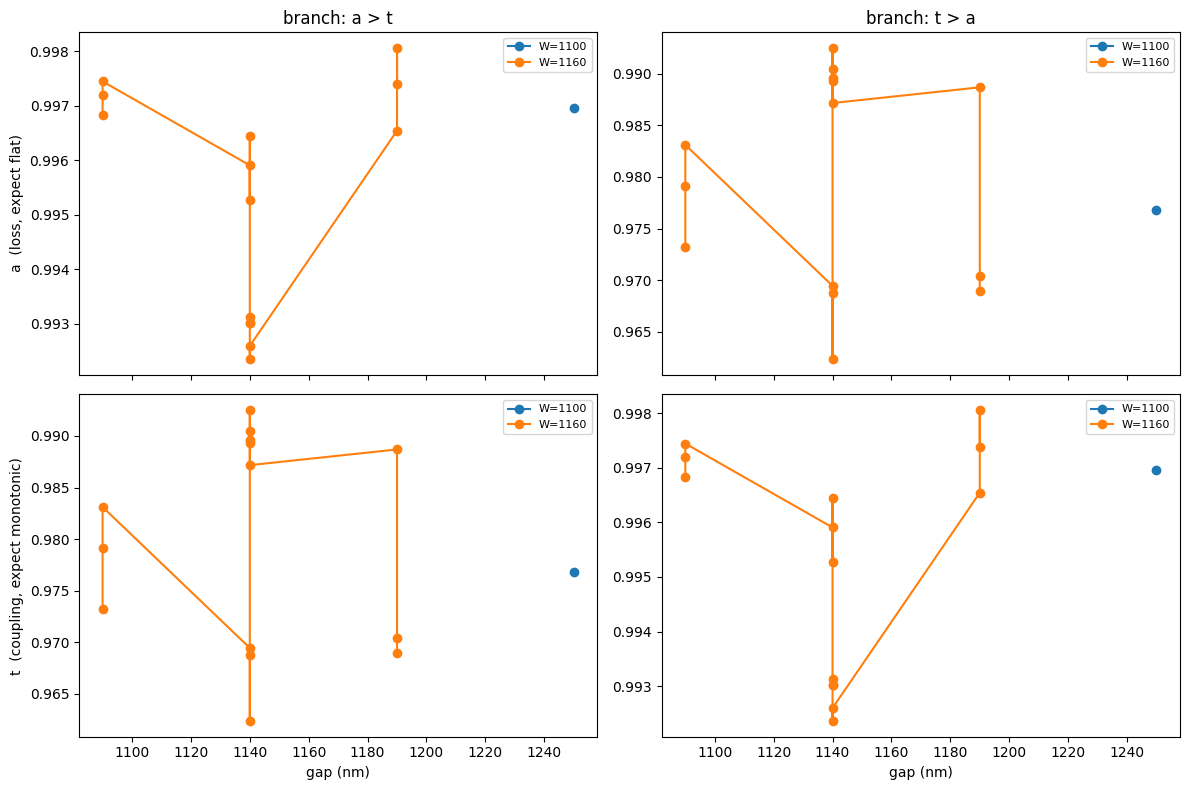

Pick the branch above that shows flat 'a' and monotonic 't' vs. gap, then read the
corresponding 'a' column for the loss. Round-trip loss in dB (branch-agnostic once a is known):
  a>t: median a = 0.9964  ->  0.031 dB/round-trip
  t>a: median a = 0.9791  ->  0.184 dB/round-trip


In [95]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex="col")
for width_nm, g in loss_df.groupby("width_nm"):
    g = g.sort_values("gap_nm")
    axs[0, 0].plot(g["gap_nm"], g["a_branch_agt"], "o-", label=f"W={width_nm}")
    axs[1, 0].plot(g["gap_nm"], g["t_branch_agt"], "o-", label=f"W={width_nm}")
    axs[0, 1].plot(g["gap_nm"], g["a_branch_tga"], "o-", label=f"W={width_nm}")
    axs[1, 1].plot(g["gap_nm"], g["t_branch_tga"], "o-", label=f"W={width_nm}")

axs[0, 0].set_title("branch: a > t"); axs[0, 1].set_title("branch: t > a")
axs[0, 0].set_ylabel("a  (loss, expect flat)")
axs[1, 0].set_ylabel("t  (coupling, expect monotonic)")
axs[1, 0].set_xlabel("gap (nm)"); axs[1, 1].set_xlabel("gap (nm)")
for ax in axs.flat:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Pick the branch above that shows flat 'a' and monotonic 't' vs. gap, then read the")
print("corresponding 'a' column for the loss. Round-trip loss in dB (branch-agnostic once a is known):")
for branch, acol in [("a>t", "a_branch_agt"), ("t>a", "a_branch_tga")]:
    a_med = loss_df[acol].median()
    print(f"  {branch}: median a = {a_med:.4f}  ->  {-20*np.log10(a_med):.3f} dB/round-trip")


In [96]:
# Racetrack geometry: 2 straight coupling sections + 2 semicircular bends (= one full circle).
COUPLING_LENGTH_UM = 20.0  # length of each straight coupling section
RADIUS_UM = 75.0
ROUND_TRIP_LENGTH_UM = 2 * COUPLING_LENGTH_UM + 2 * np.pi * RADIUS_UM
ROUND_TRIP_LENGTH_CM = ROUND_TRIP_LENGTH_UM * 1e-4
print(f"Round-trip length: {ROUND_TRIP_LENGTH_UM:.2f} um")

LOSS_BRANCH = "a_branch_agt"  # the flat-vs-gap branch identified above

# Known length -> group index follows directly from the measured FSR (no need to assume n_g).
loss_df["group_index"] = SPEED_OF_LIGHT / (ROUND_TRIP_LENGTH_UM * 1e-6 * loss_df["fsr_ghz"] * 1e9)
loss_df["propagation_loss_db_per_cm"] = -20 * np.log10(loss_df[LOSS_BRANCH]) / ROUND_TRIP_LENGTH_CM

display_cols = ["file", "width_nm", "gap_nm", "kind", "fsr_ghz",
                 "group_index", LOSS_BRANCH, "propagation_loss_db_per_cm"]
print(loss_df[display_cols].to_string(index=False))

print(f"\nGroup index: {loss_df['group_index'].median():.4f} "
      f"(+/- {loss_df['group_index'].std():.4f} across files)")
print(f"Median propagation loss: {loss_df['propagation_loss_db_per_cm'].median():.3f} dB/cm")


Round-trip length: 511.24 um
                          file  width_nm  gap_nm kind    fsr_ghz  group_index  a_branch_agt  propagation_loss_db_per_cm
         W1100G1250SH_24_3.csv      1100    1250   SH 301.772696     1.943197      0.996950                    0.518904
         W1160G1090FF_30_1.csv      1160    1090   FF 301.772696     1.943197      0.996826                    0.540187
         W1160G1090TH_30_2.csv      1160    1090   TH 299.938134     1.955083      0.997200                    0.476373
         W1160G1090TH_30_3.csv      1160    1090   TH 301.026806     1.948012      0.997444                    0.434789
         W1160G1140FF_32_1.csv      1160    1140   FF 301.979694     1.941865      0.995907                    0.696877
         W1160G1140SH_32_2.csv      1160    1140   SH 302.347779     1.939501      0.995279                    0.803913
         W1160G1140TH_32_3.csv      1160    1140   TH 303.358961     1.933036      0.996438                    0.606294
W1160G1140T